In [11]:
%matplotlib inline
from sklearn.datasets import load_digits
from matplotlib import pyplot as plt
import numpy as np

In [ ]:
X, y = load_digits(return_X_y=True)

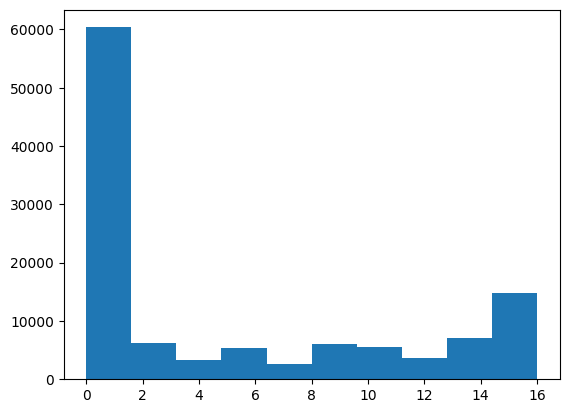

In [10]:
plt.hist(X.flatten())
plt.show()

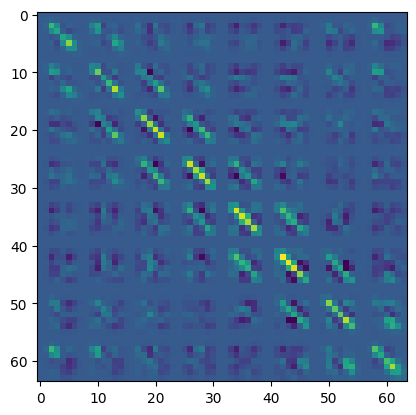

In [113]:
plt.imshow(np.cov(X.T))
plt.show()

In [114]:
s, v, d = np.linalg.svd(np.cov(X.T))
x1, x2 = (X @ s)[:, :2].T

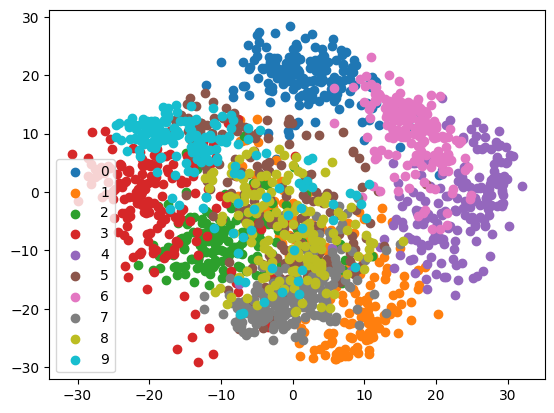

In [30]:

for _y in np.unique(y):
    plt.scatter(x1[y==_y], x2[y==_y], label=_y)
plt.legend()
plt.show()

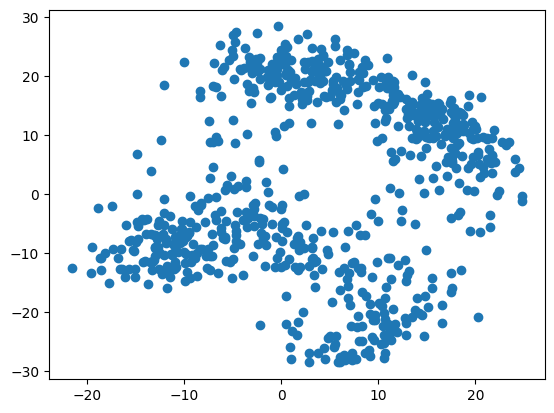

In [119]:
xs, ys = [], []

for _y in [0, 2, 1, 6]:
    xs.extend(x1[y==_y])
    ys.extend(x2[y==_y])
pts = np.array([xs, ys]).T
plt.scatter(xs, ys)
plt.show()

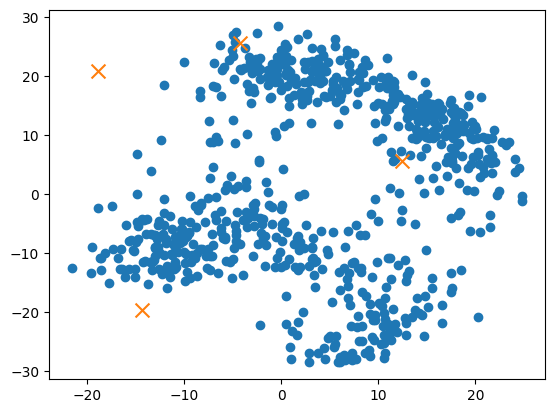

In [111]:
np.random.seed(42)
k = 4
seeds = np.random.random((k, 2))
pts = np.array([xs, ys]).T
_min, _max = pts.min(axis=0), pts.max(axis=0)
seeds = seeds * (_max - _min) + _min
plt.scatter(xs, ys)
plt.scatter(seeds[:, 0], seeds[:, 1], marker="x", s=100)
plt.show()

In [ ]:
def calculate_distance(pt1, pt2):

    return np.linalg.norm(pt1-pt2,)

In [77]:
def search_nearst_n(target_pts, pts_set, n):

    dist = np.linalg.norm(pts_set - target_pts, axis=1)

    return pts_set[np.argsort(dist)[:n]]

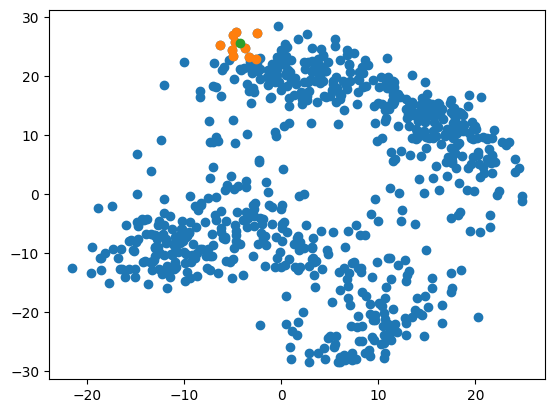

In [82]:
seed = seeds[0]
nearest_pts = search_nearst_n(seeds[0], pts, 10)
plt.scatter(xs, ys)
plt.scatter(nearest_pts[:, 0],nearest_pts[:, 1])
plt.scatter(seed[0], seed[1])
plt.show()

In [83]:
def assign_label(pts, seeds):

    dist_matrix = np.zeros((pts.shape[0], seeds.shape[0]))
    for i, seed in enumerate(seeds):

        dist_matrix[:, i] = np.linalg.norm(pts - seed, axis=1)

    return np.argmin(dist_matrix, axis=1)

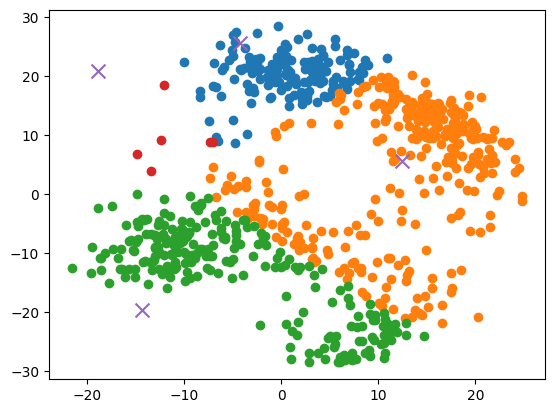

In [ ]:
labels = assign_label(pts, seeds)
for l in np.unique(labels):

    plt.scatter(pts[labels==l][:, 0], pts[labels==l][:, 1])

plt.scatter(seeds[:, 0], seeds[:, 1], marker="x", s=100)
plt.show()

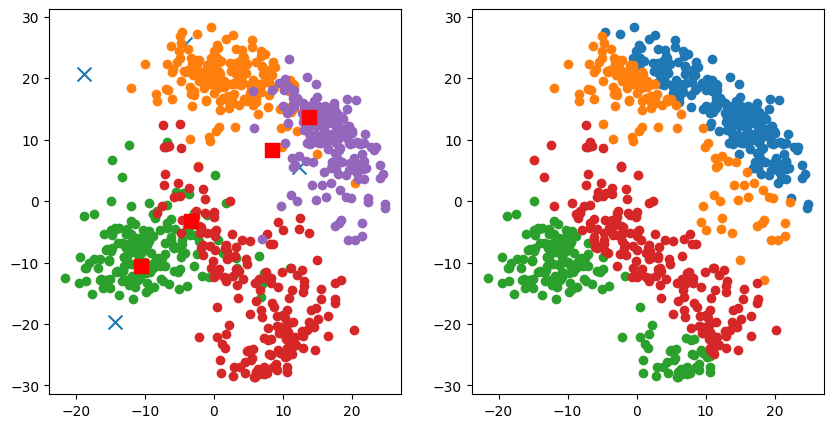

In [ ]:
np.random.seed(42)
k = 4
seeds = np.random.random((k, 2))
pts = np.array([xs, ys]).T
_min, _max = pts.min(axis=0), pts.max(axis=0)
seeds = seeds * (_max - _min) + _min
_, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].scatter(seeds[:, 0], seeds[:, 1], marker="x", s=100)

learning_rate = 1e-1
for _ in range(300):

    labels = assign_label(pts, seeds)

    for i, seed in enumerate(seeds):

        new_seed = pts[labels == i].mean()

        delta = new_seed - seed

        seeds[i] = seed + delta# * learning_rate

for _y in [0, 2, 1, 6]:
    axes[0].scatter(x1[y==_y], x2[y==_y], label=_y)
axes[0].scatter(seeds[:, 0], seeds[:, 1], marker="s", s=100, c="red")

labels = assign_label(pts, seeds)
for l in np.unique(labels):

    axes[1].scatter(pts[labels==l][:, 0], pts[labels==l][:, 1])

plt.show()

In [ ]:
from sklearn.cluster import KMeans

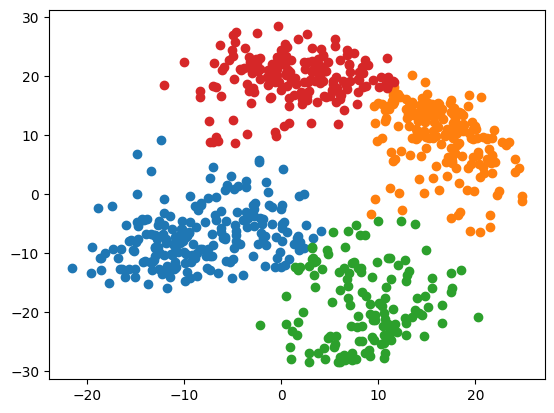

In [120]:

kmeans = KMeans(n_clusters=4, random_state=0, n_init="auto").fit(pts)
labels = kmeans.labels_
for l in np.unique(labels):

    plt.scatter(pts[labels==l][:, 0], pts[labels==l][:, 1])


In [123]:
all_pts = np.array([x1, x2]).T

kmeans = KMeans(n_clusters=10, random_state=0, n_init="auto")
# kmeans.fit(all_pts)
# labels = kmeans.labels_
# for l in np.unique(labels):
#     plt.scatter(all_pts[labels==l][:, 0], all_pts[labels==l][:, 1])

In [125]:
kmeans.init

'k-means++'